In [1]:

import sys
import os
import json
import joblib
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR) # streaming_emulator
DATA_DIR = os.path.join(ROOT_DIR, "data", "vehicles", "sim001")
ARTIFACTS_DIR = os.path.join(ROOT_DIR, "inference_service", "artifacts")
OUTPUT_DIR = os.path.join(CURRENT_DIR, "output")

# Simulation Settings
SIM_ID = "sim001"
SCENARIO = "scenarioA"
MODULES = ["engine", "body", "battery", "transmission", "tyre"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"🚀 Device: {DEVICE}")
print(f"📂 Data Source: {DATA_DIR}")
     

🚀 Device: cpu
📂 Data Source: C:\streaming_emulator\data\vehicles\sim001


In [2]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, window_size, hidden_dim=64, num_layers=2):
        super().__init__()
        self.window_size = window_size
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.0)
        self.decoder = nn.LSTM(hidden_dim, input_dim, num_layers, batch_first=True, dropout=0.0)
    
    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        context = hidden[-1].unsqueeze(1).repeat(1, self.window_size, 1)
        rec, _ = self.decoder(context)
        return rec

In [3]:
def validate_vehicle_schema(modules, sim_id):
    print(f"\n🛡️ PRE-FLIGHT CHECK FOR {sim_id.upper()}...")
    global_status = True
    module_reports = {}

    for mod in modules:
        filename = f"synthetic_{mod}_inference_{SCENARIO}_{sim_id}.csv"
        csv_path = os.path.join(DATA_DIR, filename)
        meta_path = os.path.join(ARTIFACTS_DIR, mod, "model_meta.json")
        
        if not os.path.exists(csv_path) or not os.path.exists(meta_path):
            print(f"   ❌ {mod.upper()}: Files Missing (Checked for {filename})")
            global_status = False
            continue
            
        try:
            with open(meta_path) as f: meta = json.load(f)
            expected_features = meta["features"]
            
            df_cols = pd.read_csv(csv_path, nrows=0).columns.tolist()
            available_raw = set(df_cols)
            
            missing_features = []
            missing_raw_cols = set()
            
            for feat in expected_features:
                raw = feat.replace('_mean', '').replace('_std', '')
                if raw not in available_raw:
                    missing_features.append(feat)
                    missing_raw_cols.add(raw)
            
            # --- FIXED LOGIC: We check missing RAW sensors, not derived features ---
            raw_missing_count = len(missing_raw_cols)
            
            if raw_missing_count > 3:
                print(f"   ⛔ {mod.upper()}: CRITICAL. Missing {raw_missing_count} Physical Sensors.")
                print("      Missing Sensors:")
                for raw_col in sorted(missing_raw_cols):
                    print(f"        - {raw_col}")
                print(f"      (This breaks {len(missing_features)} model features. Aborting.)")
                global_status = False
                
            elif raw_missing_count > 0:
                print(f"   ⚠️  {mod.upper()}: WARNING. Missing {raw_missing_count} Physical Sensors.")
                for raw_col in sorted(missing_raw_cols):
                    print(f"        - {raw_col}")
                print(f"      (Masking {len(missing_features)} derived features to protect Health Score.)")
                module_reports[mod] = missing_features # We pass the derived features to the mask
            else:
                print(f"   ✅ {mod.upper()}: OK")
                module_reports[mod] = []
                
        except Exception as e:
            print(f"   ❌ {mod.upper()}: Error - {e}")
            global_status = False

    return global_status, module_reports

In [4]:

def run_masked_inference(module_name, missing_features):
    print(f"   ⚙️  Inferencing: {module_name}...")
    
    filename = f"synthetic_{module_name}_inference_{SCENARIO}_{SIM_ID}.csv"
    df = pd.read_csv(os.path.join(DATA_DIR, filename))
    timestamps = pd.to_datetime(df['timestamp']) if 'timestamp' in df.columns else pd.to_datetime(df['date'])
    
    path = os.path.join(ARTIFACTS_DIR, module_name)
    with open(os.path.join(path, "model_meta.json")) as f: meta = json.load(f)
    scaler = joblib.load(os.path.join(path, "scaler.pkl"))
    iforest = joblib.load(os.path.join(path, "iforest.pkl"))
    
    lstm = LSTMAutoencoder(meta["input_dim"], meta["window_size"]).to(DEVICE)
    lstm.load_state_dict(torch.load(os.path.join(path, "lstm_model.pt"), map_location=DEVICE))
    lstm.eval()
    
    df_numeric = df.select_dtypes(include=[np.number]).copy()
    new_feats = {}
    for col in df_numeric.columns:
        new_feats[f'{col}_mean'] = df_numeric[col].rolling(window=5).mean()
        new_feats[f'{col}_std'] = df_numeric[col].rolling(window=5).std()
    
    df_eng = pd.concat([df_numeric, pd.DataFrame(new_feats, index=df.index)], axis=1).bfill().ffill()
    
    expected_cols = meta["features"]
    df_final = df_eng.reindex(columns=expected_cols, fill_value=0.0)
    
    # mask_indices expects the exact model features (e.g., 'rpm', 'rpm_mean', 'rpm_std')
    mask_indices = [expected_cols.index(c) for c in missing_features]
    
    try:
        X_scaled = scaler.transform(df_final)
    except Exception as e:
        print(f"      ❌ Scaler failed: {e}")
        return None
        
    window_size = meta["window_size"]
    sequences = [X_scaled[i : i + window_size] for i in range(len(X_scaled) - window_size + 1)]
    if not sequences: return None
    
    X_tensor = torch.tensor(np.array(sequences), dtype=torch.float32).to(DEVICE)
    results = []
    calib = meta["calibration"]
    
    with torch.no_grad():
        for i in range(0, len(X_tensor), 512):
            batch = X_tensor[i : i+512]
            rec = lstm(batch)
            
            diff = (batch - rec)**2
            if mask_indices:
                mask = torch.ones_like(diff)
                mask[:, :, mask_indices] = 0.0
                diff = diff * mask
            
            rec_error = torch.mean(diff, dim=(1,2)).cpu().numpy()
            feat_diff = diff[:, -1, :].cpu().numpy()
            anomalies = iforest.predict(batch.view(batch.shape[0], -1).cpu().numpy())
            
            for j in range(len(batch)):
                err = float(rec_error[j])
                norm = min(max((err - calib["error_min"]) / (calib["error_max"] - calib["error_min"] + 1e-6), 0.0), 1.0)
                comp = min(norm + 0.3, 1.0) if anomalies[j] == -1 else norm
                
                sev, code = ("NORMAL", 0)
                if comp > 0.8 or err > calib["threshold"]: sev, code = ("CRITICAL", 2)
                elif comp > 0.5: sev, code = ("WARNING", 1)
                
                row_feats = feat_diff[j]
                top_k = {expected_cols[k]: float(row_feats[k]) for k in np.argsort(row_feats)[-3:][::-1]}
                
                results.append({
                    "timestamp": timestamps.iloc[i+j+window_size-1],
                    "module": module_name,
                    "lstm_raw_error": err,
                    "composite_score": comp,
                    "health_score": (1.0 - comp) * 100,
                    "severity": sev,
                    "top_features": json.dumps(top_k)
                })
                
    return pd.DataFrame(results)

In [5]:

is_go, report = validate_vehicle_schema(MODULES, SIM_ID)
final_results = {}

if is_go:
    print(f"\n🚀 RUNNING INFERENCE...")
    for mod in MODULES:
        df_res = run_masked_inference(mod, report[mod])
        if df_res is not None and not df_res.empty:
            df_res.to_csv(os.path.join(OUTPUT_DIR, f"{mod}_inference.csv"), index=False)
            final_results[mod] = df_res
            print(f"      ✅ {mod}: {len(df_res)} rows.")
else:
    print("\n❌ ABORTED due to schema violations. Fix missing columns in CSV files before inferencing.")


🛡️ PRE-FLIGHT CHECK FOR SIM001...
   ⚠️  ENGINE: WARNING. Missing 1 Physical Sensors.
        - run_time_since_engine_start_s
      (Masking 3 derived features to protect Health Score.)
   ✅ BODY: OK
   ⚠️  BATTERY: WARNING. Missing 1 Physical Sensors.
        - boost_commanded_per_measured
      (Masking 3 derived features to protect Health Score.)
   ⚠️  TRANSMISSION: WARNING. Missing 2 Physical Sensors.
        - c_0_100_kph_time
        - c_0_60_mph_time
      (Masking 6 derived features to protect Health Score.)
   ⚠️  TYRE: WARNING. Missing 2 Physical Sensors.
        - c_100_0_kph_braking_time
        - c_60_0_mph_braking_time
      (Masking 6 derived features to protect Health Score.)

🚀 RUNNING INFERENCE...
   ⚙️  Inferencing: engine...


C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator ExtraTreeRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator IsolationForest from version 1.7.2 when using version 1.8.0. This might lead

      ✅ engine: 755991 rows.
   ⚙️  Inferencing: body...


C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator ExtraTreeRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator IsolationForest from version 1.7.2 when using version 1.8.0. This might lead

      ✅ body: 755991 rows.
   ⚙️  Inferencing: battery...


...

      ✅ battery: 755991 rows.
   ⚙️  Inferencing: transmission...


C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator ExtraTreeRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator IsolationForest from version 1.7.2 when using version 1.8.0. This might lead

      ✅ transmission: 755991 rows.
   ⚙️  Inferencing: tyre...


C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator ExtraTreeRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator IsolationForest from version 1.7.2 when using version 1.8.0. This might lead

      ✅ tyre: 641788 rows.


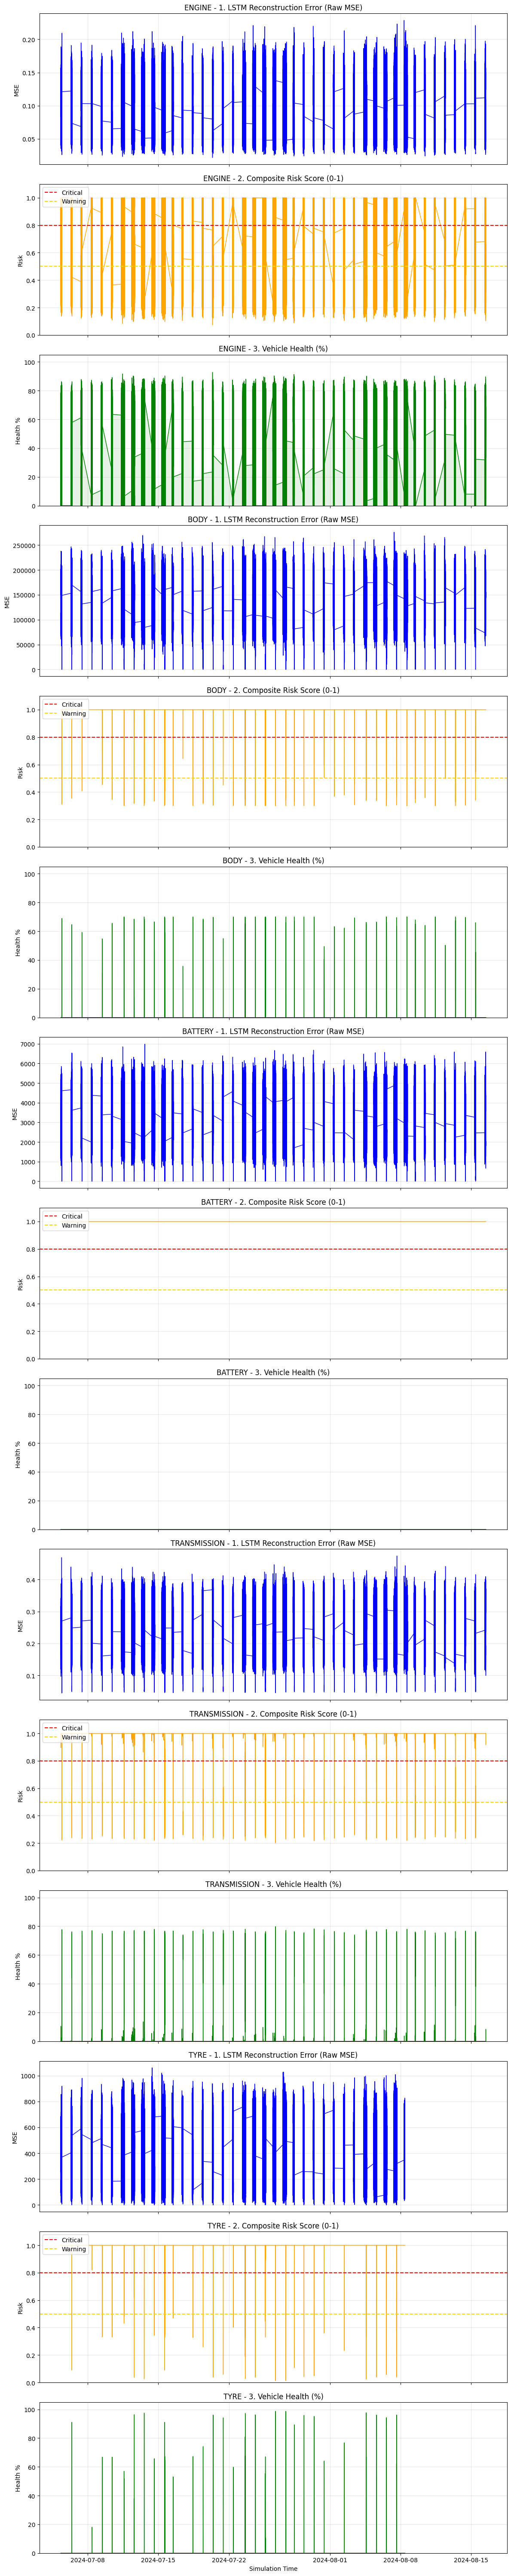

In [6]:

if not final_results:
    print("⚠️ No data to plot. Inference was aborted or failed to produce results.")
else:
    fig, axes = plt.subplots(len(final_results) * 3, 1, figsize=(12, 4 * len(final_results) * 3), sharex=True)
    if not isinstance(axes, np.ndarray): axes = [axes] # Handle single plot case
    
    idx = 0
    for mod, df in final_results.items():
        # 1. LSTM Raw Error
        ax1 = axes[idx]
        ax1.plot(df['timestamp'], df['lstm_raw_error'], color='blue', linewidth=1)
        ax1.set_title(f"{mod.upper()} - 1. LSTM Reconstruction Error (Raw MSE)")
        ax1.grid(True, alpha=0.3)
        ax1.set_ylabel("MSE")
        
        # 2. Composite Score (Risk)
        ax2 = axes[idx+1]
        ax2.plot(df['timestamp'], df['composite_score'], color='orange', linewidth=1)
        ax2.axhline(0.8, color='red', linestyle='--', label='Critical')
        ax2.axhline(0.5, color='gold', linestyle='--', label='Warning')
        ax2.set_title(f"{mod.upper()} - 2. Composite Risk Score (0-1)")
        ax2.set_ylabel("Risk")
        ax2.set_ylim(0, 1.1)
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)
        
        # 3. Health Score
        ax3 = axes[idx+2]
        ax3.plot(df['timestamp'], df['health_score'], color='green', linewidth=1)
        ax3.set_title(f"{mod.upper()} - 3. Vehicle Health (%)")
        ax3.set_ylabel("Health %")
        ax3.set_ylim(0, 105)
        ax3.fill_between(df['timestamp'], df['health_score'], 0, color='green', alpha=0.1)
        ax3.grid(True, alpha=0.3)
        
        idx += 3

    plt.xlabel("Simulation Time")
    plt.tight_layout()
    plt.show()

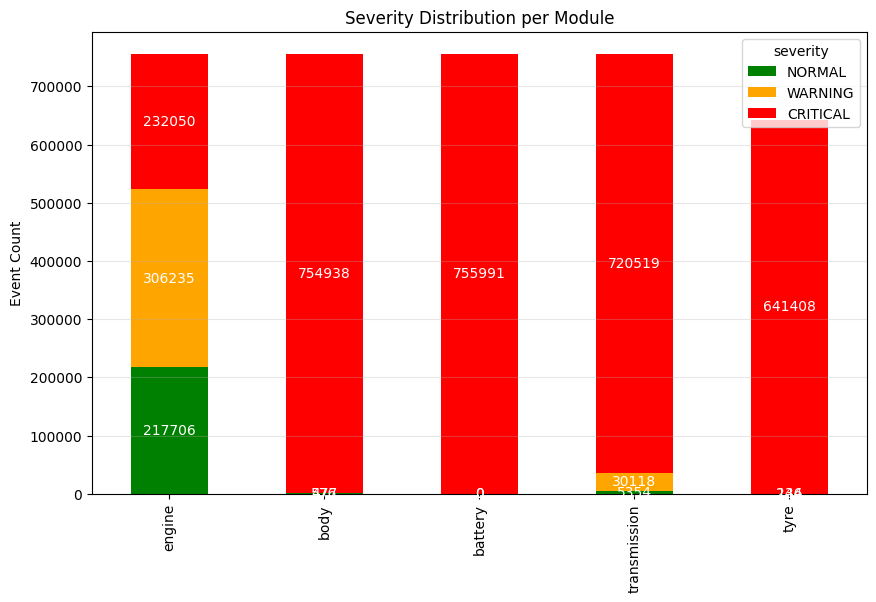

In [7]:

if not final_results:
    print("⚠️ No data to plot. Inference was aborted or failed to produce results.")
else:
    severity_counts = {}

    for mod, df in final_results.items():
        counts = df['severity'].value_counts()
        severity_counts[mod] = counts

    sev_df = pd.DataFrame(severity_counts).fillna(0).T
    for col in ['NORMAL', 'WARNING', 'CRITICAL']:
        if col not in sev_df.columns: sev_df[col] = 0
    
    sev_df = sev_df[['NORMAL', 'WARNING', 'CRITICAL']]

    ax = sev_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['green', 'orange', 'red'])
    plt.title("Severity Distribution per Module")
    plt.ylabel("Event Count")
    plt.grid(axis='y', alpha=0.3)
    
    for c in ax.containers:
        ax.bar_label(c, label_type='center', color='white')
        
    plt.show()